In [ ]:
# Step 1: Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

In [ ]:
# Step 2: Load the dataset
df = pd.read_csv("vvix_unscaled.csv")
print(df.head())

         Date  VVIX_Close  VVIX_Close_Lag_1  VVIX_Close_Lag_5  \
0  2007-02-02   72.440002         73.500000         81.360001   
1  2007-02-05   70.290001         72.440002         81.680000   
2  2007-02-06   68.550003         70.290001         78.900002   
3  2007-02-07   70.320000         68.550003         77.279999   
4  2007-02-08   73.180000         70.320000         73.500000   

   VVIX_Close_Lag_10  VVIX_Close_Lag_21  VVIX_Close_Pct_Change  \
0          82.489998          87.629997              -0.014422   
1          84.430000          88.190002              -0.029680   
2          81.480003          90.169998              -0.024755   
3          77.510002          92.040001               0.025821   
4          80.449997          92.760002               0.040671   

   VVIX_Close_Log_Return  VVIX_Close_Rolling_Mean_5  \
0              -0.014527                  76.760001   
1              -0.030129                  74.482001   
2              -0.025066                  72.41

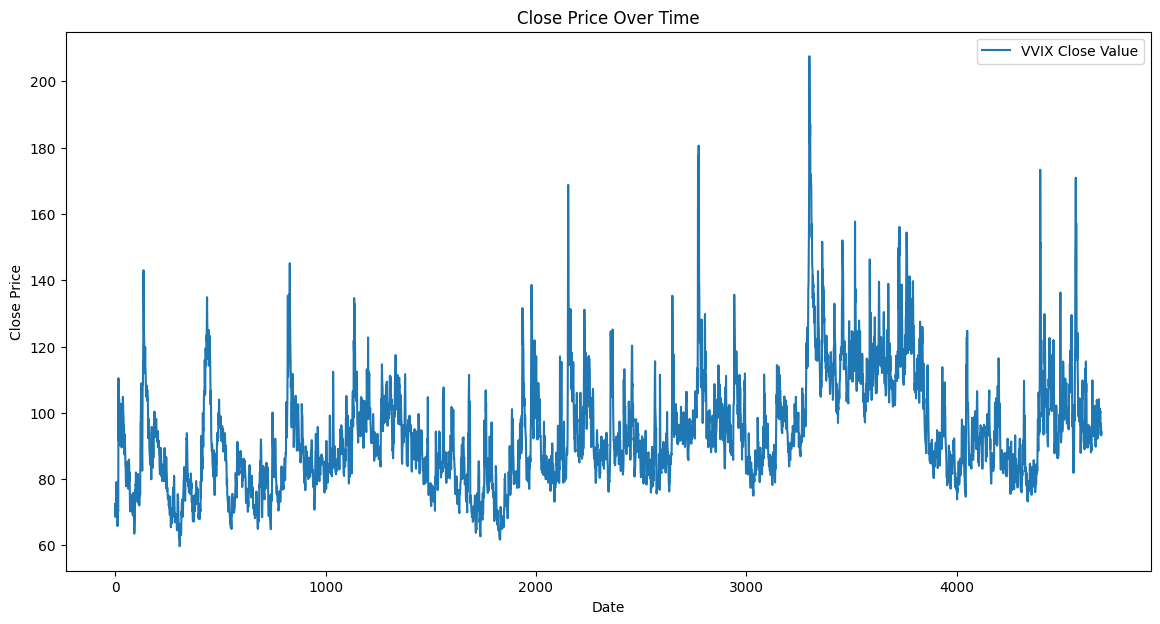

In [ ]:
# Step 3: Plot the close line
plt.figure(figsize=(14,7))
plt.plot(df.index, df["VVIX_Close"], label="VVIX Close Value")
plt.title('Close Price Over Time')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.legend()
plt.show()

In [ ]:
# Step 4: Perform the Augmented Dickey-Fuller (ADF) Test for stationarity

# I choose the VVIX_Close column
series = df['VVIX_Close'].dropna()

# Run the ADF Test
result = adfuller(series)

# Print the results of the ADF Test
print("ADF Statistic: ", result[0])
print("p-value: ", result[1])
print("Used Lags: ", result[2])
print("N Observations: ", result[3])
print("Critical Values: ", result[4])
print("IC Best: ", result[5])

ADF Statistic:  -6.532072413778208
p-value:  9.813219129626653e-09
Used Lags:  16
N Observations:  4671
Critical Values:  {'1%': np.float64(-3.431750748726974), '5%': np.float64(-2.862158969873513), '10%': np.float64(-2.5670994800621187)}
IC Best:  28603.221612961668


# The data is stationary. Strong for ARIMA.

                               SARIMAX Results                                
Dep. Variable:             VVIX_Close   No. Observations:                 4688
Model:                 ARIMA(5, 1, 0)   Log Likelihood              -14467.060
Date:                Tue, 07 Apr 2026   AIC                          28946.120
Time:                        20:36:09   BIC                          28984.835
Sample:                             0   HQIC                         28959.733
                               - 4688                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1         -0.0786      0.008     -9.618      0.000      -0.095      -0.063
ar.L2         -0.0324      0.009     -3.624      0.000      -0.050      -0.015
ar.L3         -0.0512      0.009     -5.440      0.0

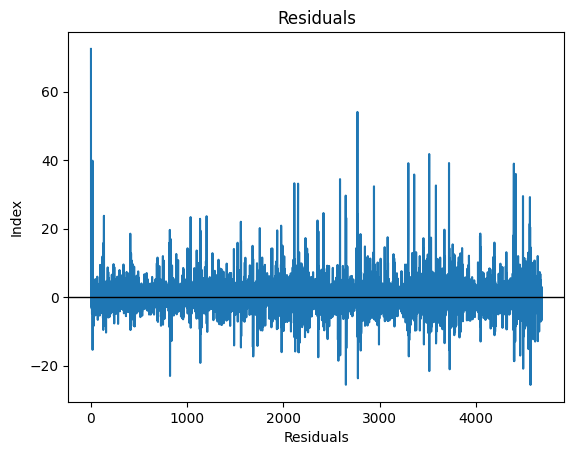

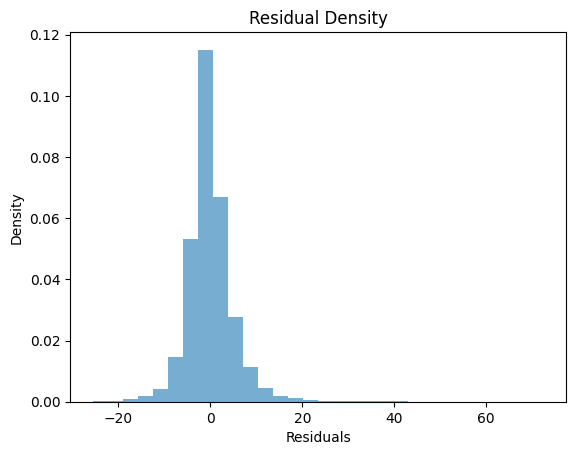

                 0
count  4688.000000
mean      0.021509
std       5.404473
min     -25.582596
25%      -2.647734
50%      -0.446517
75%       2.150809
max      72.440002


In [ ]:
# Step 5: Implement ARIMA model
model = ARIMA(series, order=(5,1,0))
fit_model = model.fit()

# Summary of the fit model
print(fit_model.summary())

# Line up a plot of residuals
resids = pd.DataFrame(fit_model.resid)
plt.plot(resids)
plt.title("Residuals")
plt.xlabel("Residuals")
plt.ylabel("Index")
plt.axhline(0, color="black", linewidth=1)
plt.show()

# Plot the density of residuals
plt.figure()
plt.hist(resids, bins=30, density=True, alpha=0.6)
plt.title('Residual Density')
plt.xlabel("Residuals")
plt.ylabel("Density")
plt.show()

# Print the summary of the residuals
print(resids.describe())

In [ ]:
# Predict the next VVIX value for the day
pred = fit_model.get_forecast(steps=1)
pred_ci = pred.conf_int()

# Print the current VVIX price and predicted VVIX price
print(f"Current VVIX Price: {series.iloc[-1]:.2f}")
print(f"Predicted VVIX Price: {pred.predicted_mean.iloc[0]:.2f}")

Current VVIX Price: 94.10
Predicted VVIX Price: 94.55


In [ ]:
# Step 6: Evaluation metrics (MSE, MAE, R2)
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

pred = fit_model.fittedvalues
actual = series.loc[pred.index]

mse = mean_squared_error(actual, pred)
mae = mean_absolute_error(actual, pred)
r2 = r2_score(actual, pred)

# Print out results
print(f"Mean Squared Error: {mse:.4f}")
print(f"Mean Absolute Error: {mae:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Squared Error: 29.2026
Mean Absolute Error: 3.5479
R2 Score: 0.8906


### Step 7: Calculate Directional Accuracy

In [ ]:
# Calculate the actual direction of change
actual_direction = np.sign(actual.diff().dropna())

# Calculate the predicted direction of change
predicted_direction = np.sign(pred.diff().dropna())

# Ensure both series have the same index for comparison
common_index = actual_direction.index.intersection(predicted_direction.index)
actual_direction = actual_direction.loc[common_index]
predicted_direction = predicted_direction.loc[common_index]

# Compare the directions
correct_directions = (actual_direction == predicted_direction).sum()
total_directions = len(actual_direction)

directional_accuracy = correct_directions / total_directions

print(f"Directional Accuracy: {directional_accuracy:.4f}")

Directional Accuracy: 0.4818
